In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.utils import load_sweep_metadata, load_data
import pandas as pd
import torch

In [ ]:
from analysis.utils import load_sweep_metadata, load_data

df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-26-cartpole_swingup-projected_sweep_uniform_data_pixelv2",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-26-cartpole_swingup-projected_sweep_uniform_data_pixelv2: 100%|██████████| 72/72 [00:00<00:00, 6130.53it/s]


Found 72 configurations
Found 72 configurations


100%|██████████| 72/72 [00:01<00:00, 49.01it/s]


In [ ]:
df['method_name'] = df['config_name'].apply(lambda x: x.split('_')[0])

In [ ]:
df['method_name'].unique()

array(['nonlinear', 'baseline', 'pca'], dtype=object)

In [ ]:
df['angle_degrees'] = df['initial_state'].apply(lambda x: int(np.degrees(x[1])))


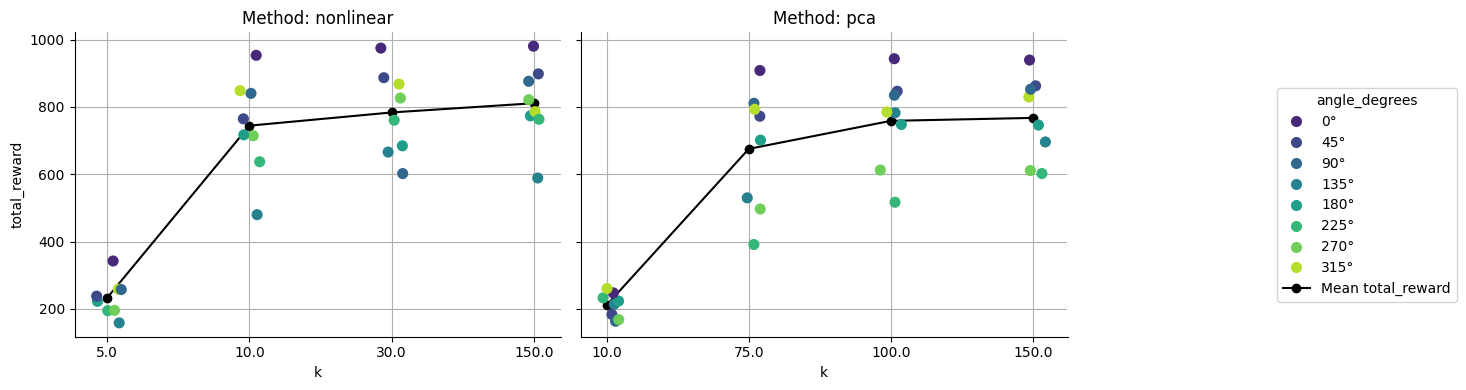

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Filter out 'baseline' method
methods_to_plot = [
    m for m in df['method_name'].unique() if m.lower() != 'baseline'
]

n_methods = len(methods_to_plot)
n_cols = 2
n_rows = (n_methods + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols + 2.5, 4 * n_rows),  # Add width for legend
    sharey=True)

# Flatten in case axes is 2D, also works if 1D
axes = axes.flatten() if n_methods > 1 else [axes]

# --- Order angle categories ---
# Get sorted unique angles
unique_angles_ordered = sorted(df['angle_degrees'].unique())
angle_labels_ordered = [f"{int(a)}°" for a in unique_angles_ordered]

# Categorize angle_degrees with ordered categories
df['angle_degrees_cat'] = pd.Categorical(
    df['angle_degrees'].astype(int).astype(str) + "°",
    categories=angle_labels_ordered,
    ordered=True)

# For color consistency: generate color palette for unique angles
palette = sns.color_palette('viridis', n_colors=len(unique_angles_ordered))
angle_to_color = dict(zip(angle_labels_ordered, palette))

legend_handles = None
legend_labels = None

for idx, (ax, method) in enumerate(zip(axes, methods_to_plot)):
    method_df = df[df['method_name'] == method]

    # Determine the sorted order used for x-axis positions (identical to stripplot's order)
    k_order = sorted(method_df['projector_config_k'].unique())

    # Use seaborn stripplot
    strip = sns.stripplot(x='projector_config_k',
                          y='total_reward',
                          hue='angle_degrees_cat',
                          palette=angle_to_color,
                          data=method_df,
                          ax=ax,
                          dodge=False,
                          jitter=True,
                          size=8,
                          order=k_order,
                          hue_order=angle_labels_ordered,
                          legend=(idx == 0))

    # Synchronize line plot x values with the categorical order of the stripplot:
    # Determine x-tick locations used by stripplot
    xticks = np.arange(len(k_order))

    # Calculate mean total_reward for each k (across all angles) for this method
    # Ensure the mean_rewards index follows the same order as k_order
    mean_rewards = (method_df.groupby('projector_config_k')
                    ['total_reward'].mean().reindex(k_order).reset_index())

    # Manually set x values as integer positions aligned with stripplot's categorical x-ticks
    ax.plot(xticks,
            mean_rewards['total_reward'],
            color='black',
            linestyle='-',
            marker='o',
            label='Mean total_reward')

    # Adjust x-axis: set correct tick positions and labels
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(k) for k in k_order])

    ax.set_xlabel('k')
    ax.set_ylabel('total_reward')
    ax.set_title(f"Method: {method}")
    ax.grid(True)
    sns.despine(ax=ax)

    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

# Hide unused subplots if any
for ax in axes[n_methods:]:
    ax.set_visible(False)

# Put the legend to the right of the last visible axis
fig.legend(
    legend_handles,
    legend_labels,
    title="angle_degrees",
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)
plt.tight_layout(rect=[0, 0, 0.87, 1])  # shrink to keep legend visible
plt.show()

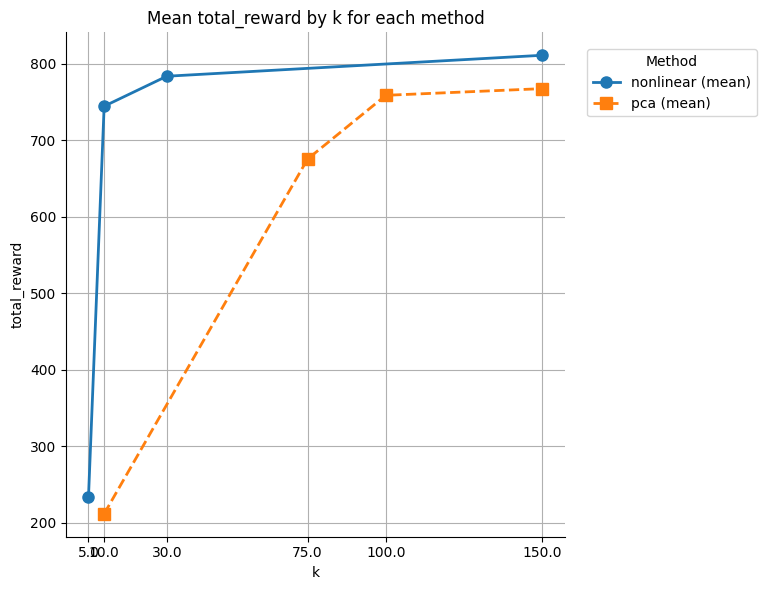

In [ ]:
# Plot the mean total_reward for each method as a function of k, making sure each method's ks may differ!

# Filter out 'baseline' method
methods_to_plot = [
    m for m in df['method_name'].unique() if m.lower() != 'baseline'
]

# Prepare color, linestyle, marker for each method
method_palette = sns.color_palette('tab10', n_colors=len(methods_to_plot))
method_to_color = dict(zip(methods_to_plot, method_palette))
method_linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]
method_markers = ['o', 's', '^', 'D', 'v', 'P', '*']

fig, ax = plt.subplots(figsize=(9, 6))

# Because not all methods have the same set of k's, treat each line's x axis per-method
for i, method in enumerate(methods_to_plot):
    method_df = df[df['method_name'] == method]
    k_order = sorted(method_df['projector_config_k'].unique())
    xticks = np.arange(len(k_order))

    # Compute mean over total_reward for each k present in this method
    mean_rewards = (method_df.groupby('projector_config_k')
                    ['total_reward'].mean().reindex(k_order).reset_index())

    ax.plot(
        k_order,  # Use true k values on x
        mean_rewards['total_reward'],
        color=method_to_color[method],
        linestyle=method_linestyles[i % len(method_linestyles)],
        marker=method_markers[i % len(method_markers)],
        label=f"{method} (mean)",
        linewidth=2,
        markersize=8,
    )

# X ticks: union of all present k's from all methods, sorted
all_ks = sorted({
    k for method in methods_to_plot
    for k in df[df['method_name'] == method]['projector_config_k'].unique()
})
ax.set_xticks(all_ks)
ax.set_xticklabels([str(k) for k in all_ks])

ax.set_xlabel('k')
ax.set_ylabel('total_reward')
ax.set_title("Mean total_reward by k for each method")
ax.grid(True)
sns.despine(ax=ax)

# Show legend for methods only
ax.legend(title="Method", loc='upper left', bbox_to_anchor=(1.03, 0.98))

plt.tight_layout(rect=[0, 0, 0.87, 1])  # shrink to keep legend visible
plt.show()

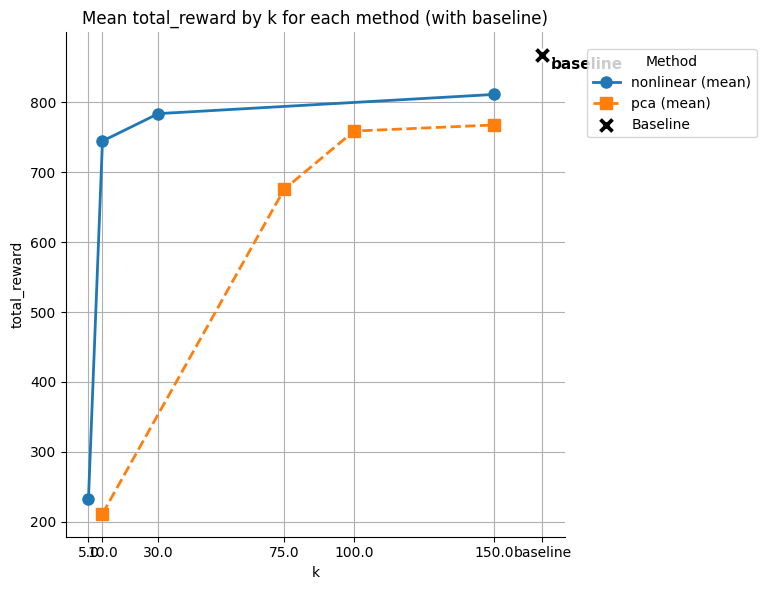

In [ ]:
# Plot the mean total_reward for each method as a function of k, making sure each method's ks may differ!
import numpy as np

# Filter out 'baseline' method for the main series, but keep it available
methods_to_plot = [
    m for m in df['method_name'].unique() if m.lower() != 'baseline'
]

# Prepare color, linestyle, marker for each method
method_palette = sns.color_palette('tab10', n_colors=len(methods_to_plot))
method_to_color = dict(zip(methods_to_plot, method_palette))
method_linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]
method_markers = ['o', 's', '^', 'D', 'v', 'P', '*']

fig, ax = plt.subplots(figsize=(9, 6))

# Because not all methods have the same set of k's, treat each line's x axis per-method
for i, method in enumerate(methods_to_plot):
    method_df = df[df['method_name'] == method]
    k_order = sorted(method_df['projector_config_k'].unique())
    xticks = np.arange(len(k_order))

    # Compute mean over total_reward for each k present in this method
    mean_rewards = (method_df.groupby('projector_config_k')
                    ['total_reward'].mean().reindex(k_order).reset_index())

    ax.plot(
        k_order,  # Use true k values on x
        mean_rewards['total_reward'],
        color=method_to_color[method],
        linestyle=method_linestyles[i % len(method_linestyles)],
        marker=method_markers[i % len(method_markers)],
        label=f"{method} (mean)",
        linewidth=2,
        markersize=8,
    )

# X ticks: union of all present k's from all methods, sorted
all_ks = sorted({
    k for method in methods_to_plot
    for k in df[df['method_name'] == method]['projector_config_k'].unique()
})

# --- Add the baseline as an extra point to the right ---

# Compute baseline mean_reward
baseline_df = df[df['method_name'].str.lower() == 'baseline']
if len(baseline_df) > 0:
    baseline_mean_reward = baseline_df['total_reward'].mean()
    # Choose a baseline x-value slightly to the right of the largest k
    if len(all_ks) > 0:
        baseline_x = max(all_ks) + (all_ks[-1] - all_ks[0]) * 0.12
    else:
        baseline_x = 1.12  # fallback
    ax.scatter([baseline_x], [baseline_mean_reward],
               color='black',
               marker='X',
               s=180,
               label='Baseline',
               zorder=10,
               edgecolors='white',
               linewidths=2)
    # Optionally, annotate
    ax.annotate('baseline',
                xy=(baseline_x, baseline_mean_reward),
                xytext=(6, -10),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

    # Extend the xticks
    all_xticks = list(all_ks) + [baseline_x]
    all_xticklabels = [str(k) for k in all_ks] + ['baseline']
else:
    all_xticks = all_ks
    all_xticklabels = [str(k) for k in all_ks]

ax.set_xticks(all_xticks)
ax.set_xticklabels(all_xticklabels)

ax.set_xlabel('k')
ax.set_ylabel('total_reward')
ax.set_title("Mean total_reward by k for each method (with baseline)")
ax.grid(True)
sns.despine(ax=ax)

# Show legend for methods only, plus baseline
ax.legend(title="Method", loc='upper left', bbox_to_anchor=(1.03, 0.98))

plt.tight_layout(rect=[0, 0, 0.87, 1])  # shrink to keep legend visible
plt.show()